# "Exploratory Data Analysis" 
## para los datos en la carpeta data/processed

In [1]:
from proyecto_ciencia_de_datos.config import PROCESSED_DATA_DIR
import pandas as pd

axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_tidy.csv', sep=',', header='infer', low_memory=False)
inegi_df = pd.read_csv(PROCESSED_DATA_DIR / 'inegi_tidy.csv', sep=',', header='infer')
weather_df = pd.read_csv(PROCESSED_DATA_DIR / 'weather_tidy.csv', sep=',', header='infer')

2025-11-09 14:14:09.150 | INFO     | proyecto_ciencia_de_datos.config:<module>:11 - PROJ_ROOT path is: D:\MasterHDXD\Escuela\Maestria\Ingenieria_de_caracteristicas\Proyecto\proyecto_ing_datos


### Primero una revision rapida de estadisticas

#### axa

In [2]:
axa_df["ESTADO"] = (
    axa_df["ESTADO"]
    .astype(str)
    .str.strip()
    .str.lower()
)
axa_df = axa_df[axa_df['ESTADO'] == 'sonora']
axa_df.head()

,SINIESTRO,LATITUD,LONGITUD,CODIGO POSTAL,CALLE,COLONIA,CAUSA SINIESTRO,TIPO VEHICULO,COLOR,MODELO,...,VOLCADURA,PERDIDA TOTAL,CONDUCTOR DISTRAIDO,FUGA,ALCOHOL,MOTOCICLETA,BICICLETA,SEGURO,TAXI,ANIMAL
2557,6184362.0,27.074450,-109.450288,85870,Calle Jesús Salido Sur,JUAREZ,COLISION Y/O VUELCO,Auto,GRIS,2008.0,...,False,False,False,False,False,False,False,False,False,False
2558,6184810.0,27.958639,-111.040313,85506,Boulevard Manlio Fabio Beltrones,SAN CARLOS,COLISION Y/O VUELCO,Auto,BLANCO,2018.0,...,False,False,False,False,False,False,False,False,False,False
2559,6184934.0,27.958639,-111.040313,85506,Boulevard Manlio Fabio Beltrones,san carlos sonora,COLISION Y/O VUELCO,Auto,NEGRO,2017.0,...,False,False,False,False,False,False,False,False,False,False
2560,6185022.0,27.935550,-110.870271,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,...,False,False,False,False,False,False,False,False,False,False
2561,6185022.0,27.935550,-110.870271,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,...,False,False,False,False,False,False,False,False,False,False


In [3]:
axa_df.info()
print("----------------------------")
axa_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 3686 entries, 2557 to 100689
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SINIESTRO            3686 non-null   float64
 1   LATITUD              3686 non-null   float64
 2   LONGITUD             3686 non-null   float64
 3   CODIGO POSTAL        3597 non-null   object 
 4   CALLE                3559 non-null   object 
 5   COLONIA              3339 non-null   object 
 6   CAUSA SINIESTRO      1796 non-null   object 
 7   TIPO VEHICULO        3683 non-null   object 
 8   COLOR                3673 non-null   object 
 9   MODELO               3683 non-null   float64
 10  NIVEL DAÑO VEHICULO  3564 non-null   object 
 11  PUNTO DE IMPACTO     867 non-null    object 
 12  AÑO                  3686 non-null   int64  
 13  MES                  3686 non-null   object 
 14  DÍA NUMERO           1796 non-null   float64
 15  DIA                  3686 non-null   o

SINIESTRO                 0
LATITUD                   0
LONGITUD                  0
CODIGO POSTAL            89
CALLE                   127
COLONIA                 347
CAUSA SINIESTRO        1890
TIPO VEHICULO             3
COLOR                    13
MODELO                    3
NIVEL DAÑO VEHICULO     122
PUNTO DE IMPACTO       2819
AÑO                       0
MES                       0
DÍA NUMERO             1890
DIA                       0
HORA                      0
ESTADO                    0
CIUDAD                    0
LESIONADOS                0
RELACION LESIONADOS    2860
EDAD LESIONADO         2146
GENERO LESIONADO       2861
NIVEL LESIONADO         926
HOSPITALIZADO             0
FALLECIDO                 0
AMBULANCIA                0
ARBOL                     0
PIEDRA                    0
DORMIDO                   0
GRUA                      0
OBRA CIVIL                0
PAVIMENTO MOJADO          0
EXPLOSION LLANTA          0
VOLCADURA                 0
PERDIDA TOTAL       

Muchos de los datos de AXA estan como FALSE y esto estaria bien si no fuera por el hecho de que algunas columnas son en su mayoria FALSE, asi que en estas tambien seria importante revisarlas

#### Inegi

In [4]:
# Solo Sonora
inegi_df = inegi_df[inegi_df['ID_ENTIDAD'] == 26]
inegi_df.head()

,COBERTURA,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,...,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS,AÑO
322981,Municipal,26,1,2018,1,0,0,0,Certificado cero,Sin accidente en esta zona,...,0,0,0,0,0,0,0,Certificado cero,Cifras Definitivas,2018
322982,Municipal,26,2,2018,1,2,51,1,Lunes,Accidente en intersección,...,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,2018
322983,Municipal,26,2,2018,1,10,0,1,Lunes,Accidente en intersección,...,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,2018
322984,Municipal,26,2,2018,1,18,2,2,Martes,Accidente en intersección,...,1,0,0,0,0,0,0,No fatal,Cifras Definitivas,2018
322985,Municipal,26,2,2018,1,19,22,2,Martes,Accidente en intersección,...,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas,2018


In [5]:
inegi_df.info()
print("----------------------------")
inegi_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 145834 entries, 322981 to 2568588
Data columns (total 46 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   COBERTURA     145834 non-null  object
 1   ID_ENTIDAD    145834 non-null  int64 
 2   ID_MUNICIPIO  145834 non-null  int64 
 3   ANIO          145834 non-null  int64 
 4   MES           145834 non-null  int64 
 5   ID_HORA       145834 non-null  int64 
 6   ID_MINUTO     145834 non-null  int64 
 7   ID_DIA        145834 non-null  int64 
 8   DIASEMANA     145834 non-null  object
 9   URBANA        145834 non-null  object
 10  SUBURBANA     145834 non-null  object
 11  TIPACCID      145834 non-null  object
 12  AUTOMOVIL     145834 non-null  int64 
 13  CAMPASAJ      145834 non-null  int64 
 14  MICROBUS      145834 non-null  int64 
 15  PASCAMION     145834 non-null  int64 
 16  OMNIBUS       145834 non-null  int64 
 17  TRANVIA       145834 non-null  int64 
 18  CAMIONETA     145834 no

COBERTURA       0
ID_ENTIDAD      0
ID_MUNICIPIO    0
ANIO            0
MES             0
ID_HORA         0
ID_MINUTO       0
ID_DIA          0
DIASEMANA       0
URBANA          0
SUBURBANA       0
TIPACCID        0
AUTOMOVIL       0
CAMPASAJ        0
MICROBUS        0
PASCAMION       0
OMNIBUS         0
TRANVIA         0
CAMIONETA       0
CAMION          0
TRACTOR         0
FERROCARRI      0
MOTOCICLET      0
BICICLETA       0
OTROVEHIC       0
CAUSAACCI       0
CAPAROD         0
SEXO            0
ALIENTO         0
CINTURON        0
ID_EDAD         0
CONDMUERTO      0
CONDHERIDO      0
PASAMUERTO      0
PASAHERIDO      0
PEATMUERTO      0
PEATHERIDO      0
CICLMUERTO      0
CICLHERIDO      0
OTROMUERTO      0
OTROHERIDO      0
NEMUERTO        0
NEHERIDO        0
CLASACC         0
ESTATUS         0
AÑO             0
dtype: int64

#### Weather

In [6]:
weather_df.head()

,FECHA_HORA,temperature_2m_max,rain_sum,showers_sum,FECHA,AÑO,MES,DIA,HORA
0,2018-01-01,29.8,NaN,NaN,2018-01-01,2018,1,1,0
1,2018-01-02,29.9,0.0,0.0,2018-01-02,2018,1,2,0
2,2018-01-03,30.3,0.0,0.0,2018-01-03,2018,1,3,0
3,2018-01-04,28.4,0.0,0.0,2018-01-04,2018,1,4,0
4,2018-01-05,31.0,0.0,0.0,2018-01-05,2018,1,5,0


In [7]:
weather_df.info()
print("----------------------------")
weather_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FECHA_HORA          2557 non-null   object 
 1   temperature_2m_max  2557 non-null   float64
 2   rain_sum            2556 non-null   float64
 3   showers_sum         2556 non-null   float64
 4   FECHA               2557 non-null   object 
 5   AÑO                 2557 non-null   int64  
 6   MES                 2557 non-null   int64  
 7   DIA                 2557 non-null   int64  
 8   HORA                2557 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 179.9+ KB
----------------------------


FECHA_HORA            0
temperature_2m_max    0
rain_sum              1
showers_sum           1
FECHA                 0
AÑO                   0
MES                   0
DIA                   0
HORA                  0
dtype: int64

In [8]:
weather_df.dropna(inplace=True)

### Exploracion de Vacios (Solo AXA tiene)
Ver que opciones podrian ser utiles antes de elegir solo dropear las columnas vacias

In [9]:
cols_con_vacios = axa_df.columns[axa_df.isnull().any()]
df_vacios_axa = axa_df[cols_con_vacios]
df_vacios_axa.head(10)

# Tener en cuenta que el total de datos es: 108670 

,CODIGO POSTAL,CALLE,COLONIA,CAUSA SINIESTRO,TIPO VEHICULO,COLOR,MODELO,NIVEL DAÑO VEHICULO,PUNTO DE IMPACTO,DÍA NUMERO,RELACION LESIONADOS,EDAD LESIONADO,GENERO LESIONADO,NIVEL LESIONADO
2557,85870,Calle Jesús Salido Sur,JUAREZ,COLISION Y/O VUELCO,Auto,GRIS,2008.0,Sin daño,Costado der delantero,1.0,NaN,0.0,NaN,NaN
2558,85506,Boulevard Manlio Fabio Beltrones,SAN CARLOS,COLISION Y/O VUELCO,Auto,BLANCO,2018.0,Bajo,Costado der central,1.0,NaN,0.0,NaN,NaN
2559,85506,Boulevard Manlio Fabio Beltrones,san carlos sonora,COLISION Y/O VUELCO,Auto,NEGRO,2017.0,Bajo,Costado izq delantero,1.0,NaN,0.0,NaN,NaN
2560,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,Bajo,Costado izq central,1.0,Tercero Pasajero,31.0,M,NaN
2561,85400,AV. García López,COLINAS DE FATIMA,COLISION Y/O VUELCO,Camión,BLANCO,2014.0,Bajo,Costado izq central,1.0,Tercero Conductor,31.0,M,NaN
2562,85000,Rodolfo Elías Calles,Ciudad Obregón Centro (Fundo Legal),COLISION Y/O VUELCO,Auto,AZUL,2018.0,Bajo,Trasero,1.0,NaN,0.0,NaN,NaN
2563,85864,Carretera Navojoa - Huatabampo,NaN,COLISION Y/O VUELCO,Auto,GUINDA,2004.0,Bajo,Costado der delantero,1.0,Conductor Asegurado,20.0,M,NaN
2564,85040,París,col bellavista,COLISION Y/O VUELCO,Auto,GRIS,2016.0,Bajo,Costado der delantero,1.0,NaN,0.0,NaN,NaN
2565,85800,Treceava,Estadio Viejo,ATROPELLO,Auto,BLANCO,2018.0,Sin daño,Costado izq central,1.0,NaN,0.0,NaN,NaN
2566,0,AJUSTE EN LINEA AMBERES 557,AJUSTE EN LINEA NAINARY DEL YAKI,COLISION Y/O VUELCO,Auto,BLANCO,0.0,NaN,NaN,2.0,NaN,0.0,NaN,NaN


In [10]:
df_vacios_axa.isna().sum()

CODIGO POSTAL            89
CALLE                   127
COLONIA                 347
CAUSA SINIESTRO        1890
TIPO VEHICULO             3
COLOR                    13
MODELO                    3
NIVEL DAÑO VEHICULO     122
PUNTO DE IMPACTO       2819
DÍA NUMERO             1890
RELACION LESIONADOS    2860
EDAD LESIONADO         2146
GENERO LESIONADO       2861
NIVEL LESIONADO         926
dtype: int64

Pero tambien es importante revisar los bool, ya que al filtrar por Sonora podria ser que no tenga tantos valores.

In [11]:
for column in axa_df.select_dtypes(include=['bool']).columns:
    true_count = axa_df[column].sum()
    if true_count > 0:
        print(f"{column}: {true_count} True values")

HOSPITALIZADO: 6 True values
FALLECIDO: 7 True values


Algunas de estas columnas tiene muy pocos vacios y otras no nos son necesarias para lo que estamos buscando explicar.De las columnas con booleanos, al contar sus valores, podemos ver que algunas son False todos sus valores o muy pocos valores son True. 

Son necesarias y aplicaremos alguna tecnica para llenarlas: 
Causa Siniestro, Tipo Vehiculo, Modelo

In [12]:
axa_df = axa_df.drop(columns=['EDAD LESIONADO', 
                              'PUNTO DE IMPACTO', 
                              'GENERO LESIONADO', 
                              'COLOR', 
                              'CODIGO POSTAL', 
                              'CALLE', 
                              'COLONIA', 
                              'DÍA NUMERO', 
                              'RELACION LESIONADOS', 
                              'NIVEL LESIONADO', 
                              'NIVEL DAÑO VEHICULO', 
                              'GRUA', 
                              'SEGURO',
                              'PERDIDA TOTAL',
                              'VOLCADURA',
                              'OBRA CIVIL',
                              'AMBULANCIA',
                              'ARBOL',
                              'PIEDRA',
                              'DORMIDO',
                              'PAVIMENTO MOJADO',
                              'ANIMAL',
                              'EXPLOSION LLANTA',
                              'CONDUCTOR DISTRAIDO',
                              'ALCOHOL',
                              'MOTOCICLETA',
                              'BICICLETA',
                              'HOSPITALIZADO',
                              'FALLECIDO',
                              'FUGA',
                              'TAXI',
                              'ESTADO'
                              ])

In [13]:
axa_df.head()

,SINIESTRO,LATITUD,LONGITUD,CAUSA SINIESTRO,TIPO VEHICULO,MODELO,AÑO,MES,DIA,HORA,CIUDAD,LESIONADOS
2557,6184362.0,27.074450,-109.450288,COLISION Y/O VUELCO,Auto,2008.0,2021,ABRIL,JUEVES,12,NAVOJOA,0
2558,6184810.0,27.958639,-111.040313,COLISION Y/O VUELCO,Auto,2018.0,2021,ABRIL,JUEVES,14,GUAYMAS,0
2559,6184934.0,27.958639,-111.040313,COLISION Y/O VUELCO,Auto,2017.0,2021,ABRIL,JUEVES,14,GUAYMAS,0
2560,6185022.0,27.935550,-110.870271,COLISION Y/O VUELCO,Camión,2014.0,2021,ABRIL,JUEVES,15,GUAYMAS,2
2561,6185022.0,27.935550,-110.870271,COLISION Y/O VUELCO,Camión,2014.0,2021,ABRIL,JUEVES,15,GUAYMAS,2


- Los siniestros nos importan por que nos dan informacion sobre el choque y puede que indique la causa del choque pero muchos datos son faltantes, asi que los vamos a sustituir por "Sin dato"

- Tipo Vehiculo y Modelo los vamos a llenar con el promedio



In [14]:
axa_df['CAUSA SINIESTRO'] = axa_df['CAUSA SINIESTRO'].fillna('Sin dato')
axa_df['TIPO VEHICULO'] = axa_df['TIPO VEHICULO'].fillna(axa_df['TIPO VEHICULO'].mode()[0])
axa_df['MODELO'] = axa_df['MODELO'].fillna(axa_df['MODELO'].mode()[0])
axa_df[['CAUSA SINIESTRO', 'TIPO VEHICULO']] = axa_df[['CAUSA SINIESTRO', 'TIPO VEHICULO']].astype('category')


In [15]:
print(axa_df.isna().sum())

SINIESTRO          0
LATITUD            0
LONGITUD           0
CAUSA SINIESTRO    0
TIPO VEHICULO      0
MODELO             0
AÑO                0
MES                0
DIA                0
HORA               0
CIUDAD             0
LESIONADOS         0
dtype: int64


## Analisis de Anomalias (Outliers)

### AXA

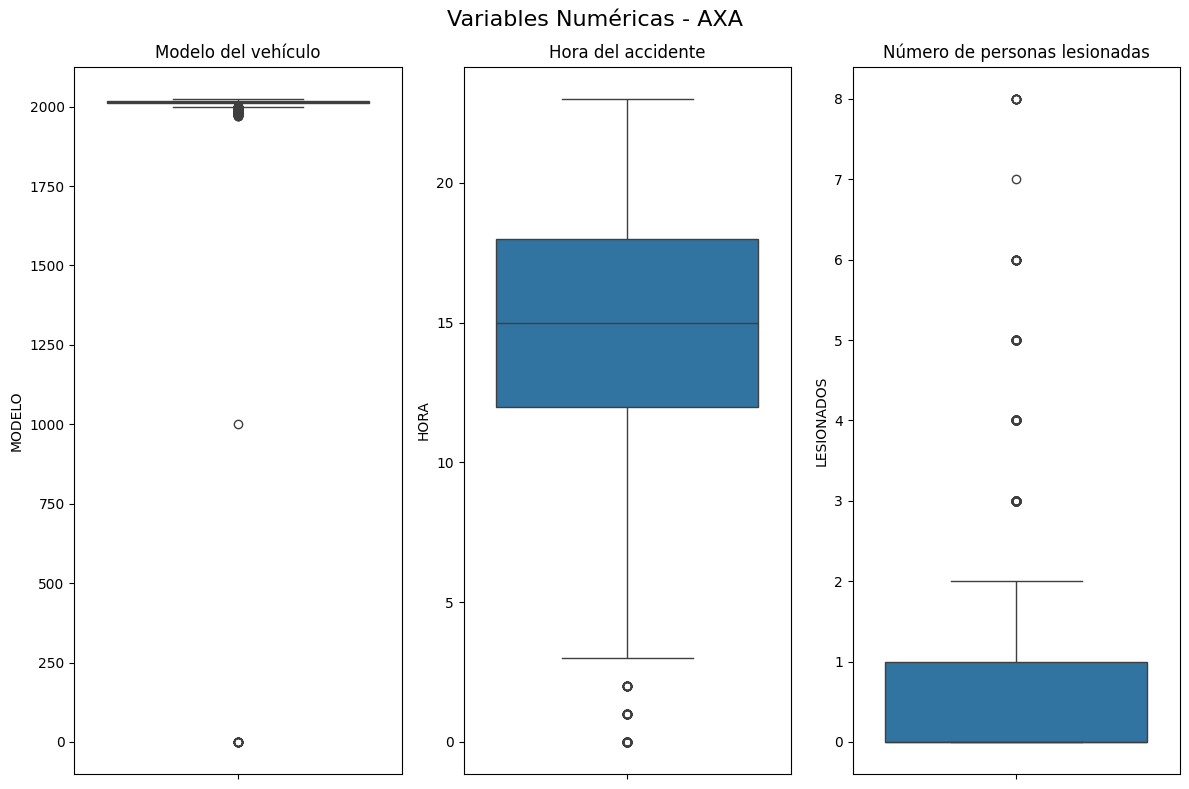

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 8))
fig.suptitle('Variables Numéricas - AXA', fontsize=16)

# Aplanar el array 2D a 1D
axes = axes.flatten()

# indexar con [0], [1], [2], [3]
sns.boxplot(data=axa_df, y='MODELO', ax=axes[0])
axes[0].set_title('Modelo del vehículo')

sns.boxplot(data=axa_df, y='HORA', ax=axes[1])
axes[1].set_title('Hora del accidente')

sns.boxplot(data=axa_df, y='LESIONADOS', ax=axes[2])
axes[2].set_title('Número de personas lesionadas')



plt.tight_layout()
plt.show()

Aunque existen outliers en la hora del accidente y en el numero de personas lesionadas, estas se encuentran dentro de los valores que se podrian esperar de accidentes, pero en los modelos de vehiculos parece haber valores raros, habra que visualizar esto.

In [17]:
print("Mayores que 2024: ", axa_df[axa_df['MODELO'] > 2024]['MODELO'].value_counts())
print("Menores que 1950: ", axa_df[axa_df['MODELO'] < 1950]['MODELO'].value_counts())

Mayores que 2024:  Series([], Name: count, dtype: int64)
Menores que 1950:  MODELO
0.0       16
1000.0     1
Name: count, dtype: int64


El primer vehiculo de la historia se fue creado alrededor de 1900, por lo tanto estos valores no encajan con el resto, sin embargo, los modelos de vehiculos deberian ser categoricos, asi que vamos a convertir esta columna a categorico y transformar el 0.0 y 1000.0 en 'Sin Dato'

In [18]:
# Convertir outlier a 0
axa_df['MODELO'] = axa_df['MODELO'].apply(lambda x: 0 if x < 1900 or x > 2024 else int(x))


In [19]:
axa_df['MODELO'].value_counts()

MODELO
2017    406
2018    362
2019    323
2016    307
2020    282
2015    221
2012    165
2014    161
2013    160
2021    124
2007     99
2022     99
2011     97
2006     92
2008     91
2023     88
2010     85
2005     82
2009     66
2003     50
2024     45
2004     40
2002     31
2000     30
2001     24
1998     20
1999     18
0        17
1995     15
1997     13
1990      9
1996      7
1992      6
1994      5
1986      5
1991      5
1993      4
1981      4
1987      3
1970      3
1988      3
1984      3
1985      3
1975      2
1974      2
1978      2
1976      2
1977      2
1989      1
1983      1
1982      1
Name: count, dtype: int64

### INEGI

In [20]:
"""
Análisis de Outliers Específico para Dataset INEGI
Basado en el diccionario de datos oficial
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================================
# VALIDACIÓN DE RANGOS PERMITIDOS (Detectar Errores de Captura)
# ============================================================================

def validar_rangos_inegi(df):
    """
    Valida que los valores estén dentro de rangos permitidos según el diccionario
    """
    print("=" * 80)
    print("VALIDACIÓN DE RANGOS PERMITIDOS")
    print("=" * 80)
    
    validaciones = {
        'ID_HORA': {'min': 0, 'max': 23, 'especial': [99], 'descripcion': 'Hora (99=no especificado)'},
        'ID_MINUTO': {'min': 0, 'max': 59, 'especial': [99], 'descripcion': 'Minutos (99=no especificado)'},
        'ID_DIA': {'min': 1, 'max': 31, 'especial': [32], 'descripcion': 'Día (32=no especificado)'},
        'ID_EDAD': {'min': 0, 'max': 99, 'especial': [0, 99], 'descripcion': 'Edad (0=fugado, 99=se ignora)'},
        'MES': {'min': 1, 'max': 12, 'especial': [], 'descripcion': 'Mes'},
        'ANIO': {'min': 1997, 'max': 2024, 'especial': [], 'descripcion': 'Año'}
    }
    
    resultados = []
    
    for columna, reglas in validaciones.items():
        if columna in df.columns:
            # Convertir a numérico si es necesario
            valores = pd.to_numeric(df[columna], errors='coerce')
            
            # Detectar valores fuera de rango (excluyendo valores especiales)
            fuera_rango = valores[
                ~valores.isin(reglas['especial']) & 
                ((valores < reglas['min']) | (valores > reglas['max']))
            ]
            
            n_fuera = len(fuera_rango)
            pct_fuera = (n_fuera / len(df)) * 100
            
            resultados.append({
                'Variable': columna,
                'Descripción': reglas['descripcion'],
                'Rango_Válido': f"{reglas['min']}-{reglas['max']}",
                'Valores_Especiales': str(reglas['especial']),
                'Fuera_Rango': n_fuera,
                'Porcentaje': f"{pct_fuera:.3f}%"
            })
            
            if n_fuera > 0:
                print(f"\n⚠️  {columna}: {n_fuera} valores fuera de rango ({pct_fuera:.3f}%)")
                print(f"    Valores únicos fuera de rango: {fuera_rango.unique()[:10]}")
    
    return pd.DataFrame(resultados)


# Ejemplo de uso (descomenta cuando tengas el dataframe cargado):
# analisis_completo_inegi(inegi_df)

# O ejecuta análisis individuales:
df_validacion = validar_rangos_inegi(inegi_df)
print("\nResumen de validación de rangos:")
print(df_validacion.to_string(index=False))
# carambolas = analizar_vehiculos_involucrados(inegi_df)
# catastroficos = analizar_victimas(inegi_df)
# analizar_patrones_temporales(inegi_df)

VALIDACIÓN DE RANGOS PERMITIDOS

⚠️  ID_DIA: 431 valores fuera de rango (0.296%)
    Valores únicos fuera de rango: [0]

Resumen de validación de rangos:
 Variable                   Descripción Rango_Válido Valores_Especiales  Fuera_Rango Porcentaje
  ID_HORA     Hora (99=no especificado)         0-23               [99]            0     0.000%
ID_MINUTO  Minutos (99=no especificado)         0-59               [99]            0     0.000%
   ID_DIA      Día (32=no especificado)         1-31               [32]          431     0.296%
  ID_EDAD Edad (0=fugado, 99=se ignora)         0-99            [0, 99]            0     0.000%
      MES                           Mes         1-12                 []            0     0.000%
     ANIO                           Año    1997-2024                 []            0     0.000%


In [21]:
inegi_df['ID_DIA'].describe()

count    145834.000000
mean         15.760536
std           8.918249
min           0.000000
25%           8.000000
50%          16.000000
75%          24.000000
max          31.000000
Name: ID_DIA, dtype: float64

Segun el diccionario de datos, no deberia haber dias con el valor 0, por lo tanto estos los vamos a convertir a 32, el cual es el valor especificado para dias no especificados

In [22]:
inegi_df['ID_DIA'].replace(0, 32)

322981     32
322982      1
322983      1
322984      2
322985      2
           ..
2568584    26
2568585    28
2568586    30
2568587    30
2568588     2
Name: ID_DIA, Length: 145834, dtype: int64

### Weather

In [23]:
"""
Local Outlier Factor (LOF) con visualización de anomaly scores
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ============================================================================
# LOF - DETECCIÓN
# ============================================================================

def detectar_outliers_lof(df, columnas, n_neighbors=20, contamination=0.05):
    """
    Detecta outliers usando Local Outlier Factor
    
    Parámetros:
    -----------
    df : DataFrame
    columnas : list - columnas numéricas a analizar
    n_neighbors : int - número de vecinos (mayor = más global, menor = más local)
    contamination : float - proporción esperada de outliers (0.05 = 5%)
    
    Retorna:
    --------
    DataFrame con columnas 'outlier_LOF' y 'lof_score'
    """
    # Preparar datos
    X = df[columnas].values
    
    # Entrenar LOF
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=False
    )
    
    # Predecir (-1 = outlier, 1 = normal)
    predicciones = lof.fit_predict(X)
    
    # Obtener scores (más negativo = más anómalo)
    scores = lof.negative_outlier_factor_
    
    # Agregar al dataframe
    df_resultado = df.copy()
    df_resultado['outlier_LOF'] = predicciones
    df_resultado['lof_score'] = scores
    
    # Score normalizado (más intuitivo: valores altos = más anómalo)
    # LOF score de 1 = normal, >1 = outlier
    df_resultado['lof_factor'] = -scores  # Invertir para que sea más intuitivo
    
    return df_resultado, lof


# ============================================================================
# RESUMEN ESTADÍSTICO
# ============================================================================

def resumen_lof(df_lof, columnas):
    """
    Genera reporte estadístico de outliers detectados por LOF
    """
    mask_outliers = df_lof['outlier_LOF'] == -1
    outliers = df_lof[mask_outliers]
    normales = df_lof[~mask_outliers]
    
    print("=" * 80)
    print("RESUMEN LOF (LOCAL OUTLIER FACTOR)")
    print("=" * 80)
    
    print(f"\n📊 Información General:")
    print(f"   - Total observaciones: {len(df_lof)}")
    print(f"   - Outliers detectados: {len(outliers)} ({len(outliers)/len(df_lof)*100:.2f}%)")
    print(f"   - Normales: {len(normales)} ({len(normales)/len(df_lof)*100:.2f}%)")
    
    print(f"\n📈 LOF Scores:")
    print(f"   - LOF Factor promedio (todos): {df_lof['lof_factor'].mean():.3f}")
    print(f"   - LOF Factor máximo: {df_lof['lof_factor'].max():.3f}")
    print(f"   - LOF Factor mínimo: {df_lof['lof_factor'].min():.3f}")
    print(f"   - LOF Factor promedio (outliers): {outliers['lof_factor'].mean():.3f}")
    
    print(f"\n🔍 Top 10 outliers más extremos:")
    top_outliers = df_lof.nlargest(10, 'lof_factor')
    print(top_outliers[columnas + ['lof_factor']].to_string(index=False))
    
    print("\n" + "=" * 80)
    
    return outliers

# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def analisis_completo_lof(weather_df, columnas, n_neighbors=20, contamination=0.05):
    """
    Análisis completo con LOF
    """
    print("🔄 Ejecutando LOF...")
    
    # Detectar outliers
    df_lof, modelo = detectar_outliers_lof(
        weather_df, 
        columnas, 
        n_neighbors=n_neighbors,
        contamination=contamination
    )
    
    # Guardar parámetros en el dataframe
    df_lof.attrs['n_neighbors'] = n_neighbors
    df_lof.attrs['contamination'] = contamination
    
    # Resumen estadístico
    outliers = resumen_lof(df_lof, columnas)
    
    print("\n✅ Análisis completo")
    
    return df_lof, outliers

# ============================================================================
# EJEMPLO DE USO
# ============================================================================
columnas=['temperature_2m_max','rain_sum','showers_sum']


# Now run the analysis
df_resultado, outliers = analisis_completo_lof(
    weather_df,
    columnas=['temperature_2m_max','rain_sum'],
    n_neighbors=250,      # Adjust: higher = more global, lower = more local
    contamination=0.01   # Expected proportion of outliers (1%)
)


🔄 Ejecutando LOF...
RESUMEN LOF (LOCAL OUTLIER FACTOR)

📊 Información General:
   - Total observaciones: 2556
   - Outliers detectados: 26 (1.02%)
   - Normales: 2530 (98.98%)

📈 LOF Scores:
   - LOF Factor promedio (todos): 1.436
   - LOF Factor máximo: 109.876
   - LOF Factor mínimo: 0.975
   - LOF Factor promedio (outliers): 30.566

🔍 Top 10 outliers más extremos:
 temperature_2m_max  rain_sum  lof_factor
               28.8     184.1  109.875810
               40.2     129.3   88.147263
               27.1      85.6   54.273246
               38.9      76.0   52.133574
               23.6     102.7   44.659120
               35.3      65.2   42.647664
               39.1      55.1   38.350726
               37.4      51.1   34.938808
               40.0      43.2   31.128777
               41.1      35.3   25.254615


✅ Análisis completo


Aunque con LOF detectamos outliers muy grandes, estos son los registros reales del clima y realmente esta dificil detectar bien los outliers del clima en hermosillo con base a la lluvia, por el hecho de que la cantidad de dias con lluvia son muy pocos y además estos días pueden tener lluvia aunque la temperatura sea muy alta, de forma que mete más ruido a ello.